# 03 — Modelo, avaliação e explicação: a IA pega a falha antes da quebra?

Continuação de [`01_exploracao`](01_exploracao.ipynb) e [`02_preparacao`](02_preparacao.ipynb).

O treino pesado roda nos scripts (`python -m src.train`, `python -m src.evaluate`, `python -m src.explain`).
Este notebook **carrega o modelo já treinado** (`models/xgb_model.json`) e mostra, passo a passo:

1. Por que **acurácia** não serve para medir manutenção preditiva;
2. Como o modelo foi treinado sem "espiar" o teste;
3. Os resultados no teste: baseline × XGBoost;
4. O **limiar de alarme** como uma decisão de manutenção;
5. Onde o modelo erra — e por quê;
6. O que o **SHAP** diz sobre quais sensores importam e por que uma máquina específica foi sinalizada;
7. Limitações honestas.

> Todos os números vêm do código executado abaixo ou dos arquivos gerados pelos scripts (`models/metrics.json`).

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.features import load_processed
from src.train import METRICS_PATH, get_cv, load_threshold_config, make_xgb
from src.evaluate import (bootstrap_ci, compute_metrics, naive_metrics, plot_confusion_matrix,
                          plot_pr_curves, plot_threshold_curve, predict_test)
from src.explain import (FAILURE_MODES, TITULOS, compute_test_shap, describe_case, mean_abs_shap,
                         plot_beeswarm, plot_importance, plot_waterfall, select_cases)

%matplotlib inline
pd.set_option("display.precision", 3)

metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))
config = load_threshold_config()
X_train, X_test, y_train, y_test = load_processed()
_, _, proba_base, proba_xgb, _ = predict_test()
THR = float(config["threshold"])
THR_BASE = float(config["baseline_threshold"])
print(f"Treino: {len(y_train)} linhas ({int(y_train.sum())} falhas) | Teste: {len(y_test)} linhas ({int(y_test.sum())} falhas)")

Treino: 8000 linhas (271 falhas) | Teste: 2000 linhas (68 falhas)


## 1. Por que não usar acurácia?

No chão de fábrica, a pergunta que importa é: **"de cada 10 falhas, quantas o sistema avisou antes?"** — isso é o **recall**.
Como só ~3,4% dos registros são falhas, um "modelo" que **nunca** dá alarme já tem acurácia altíssima. Veja:

In [2]:
ingenuo = naive_metrics(y_test)
print(f"Modelo 'nunca falha' -> acurácia: {ingenuo['acuracia']:.2%} | recall: {ingenuo['recall']:.0%} "
      f"| falhas detectadas: {ingenuo['falhas_detectadas']}")

Modelo 'nunca falha' -> acurácia: 96.60% | recall: 0% | falhas detectadas: 0 de 68


Uma acurácia de quase 97% que **não detecta nenhuma falha**. Na prática, é o mesmo que não ter monitoramento.
Por isso este projeto usa:

- **Recall**: fração das falhas reais que geraram alarme (falha não detectada = máquina parada sem aviso, peça refugada, manutenção corretiva de emergência);
- **Precisão**: fração dos alarmes que eram falha de verdade (alarme falso = parada ou inspeção desnecessária);
- **PR-AUC** (área sob a curva precisão × recall): resume a qualidade do modelo em todos os limiares, focando na classe rara. Um sorteio aleatório teria PR-AUC ≈ 0,034 (a proporção de falhas).
- **F2**: combina precisão e recall dando **peso maior ao recall**, porque deixar passar uma falha costuma custar mais que uma parada para inspeção.

## 2. Como o modelo foi treinado (sem espiar o teste)

- **Baseline**: regressão logística com dados padronizados e `class_weight='balanced'`.
- **Modelo principal**: XGBoost com `scale_pos_weight` = (sem falha ÷ falha) no treino, para compensar o desbalanceamento.
- **Busca de hiperparâmetros** pequena (20 combinações), com **validação cruzada estratificada de 5 dobras só no treino**, otimizando PR-AUC.
- O **conjunto de teste** (2.000 registros) ficou trancado até a avaliação final.

In [3]:
busca = metrics["busca_hiperparametros"]
print("Método:", busca["metodo"])
print("scale_pos_weight:", metrics["treino"]["scale_pos_weight"])
print("Melhores hiperparâmetros:", busca["melhores_parametros"])
print(f"PR-AUC na validação cruzada (XGBoost): {busca['pr_auc_cv_media']:.3f} ± {busca['pr_auc_cv_desvio']:.3f}")
pd.DataFrame(metrics["cv_oof"]).T.rename_axis("modelo (out-of-fold no treino)")

Método: RandomizedSearchCV, 20 combinações, scoring=average_precision
scale_pos_weight: 28.5203
Melhores hiperparâmetros: {'subsample': 0.85, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
PR-AUC na validação cruzada (XGBoost): 0.837 ± 0.046


,threshold,f2_oof,precision_oof,recall_oof,pr_auc_oof,f2_oof_at_threshold
modelo (out-of-fold no treino),,,,,,
baseline,0.735,0.531,0.281,0.683,0.478,0.531
xgboost,0.497,0.802,0.726,0.823,0.838,0.802


Já na validação cruzada o XGBoost fica muito à frente do baseline em PR-AUC: as falhas dependem de **combinações não lineares** de condições (ex.: ferramenta gasta **e** torque alto), que uma regressão logística não captura bem.

## 3. Resultados no teste: baseline × XGBoost

In [4]:
linhas = []
for nome, proba, thr_esc in [("Baseline", proba_base, THR_BASE), ("XGBoost", proba_xgb, THR)]:
    for rotulo, thr in [("0,5 (padrão)", 0.5), (f"{thr_esc:.4f} (escolhido no treino)", thr_esc)]:
        m = compute_metrics(y_test, proba, thr)
        cm = m["matriz_confusao"]
        linhas.append({"modelo": nome, "limiar": rotulo, "recall": m["recall"], "precisão": m["precisao"],
                       "F1": m["f1"], "F2": m["f2"], "PR-AUC": m["pr_auc"], "ROC-AUC": m["roc_auc"],
                       "falhas detectadas": m["falhas_detectadas"], "alarmes falsos": cm["fp"]})
resultados = pd.DataFrame(linhas)
resultados

,modelo,limiar,recall,precisão,F1,F2,PR-AUC,ROC-AUC,falhas detectadas,alarmes falsos
0,Baseline,"0,5 (padrão)",0.868,0.176,0.293,0.486,0.469,0.934,59 de 68,276
1,Baseline,0.7349 (escolhido no treino),0.765,0.308,0.439,0.590,0.469,0.934,52 de 68,117
2,XGBoost,"0,5 (padrão)",0.824,0.757,0.789,0.809,0.884,0.979,56 de 68,18
3,XGBoost,0.4969 (escolhido no treino),0.824,0.757,0.789,0.809,0.884,0.979,56 de 68,18


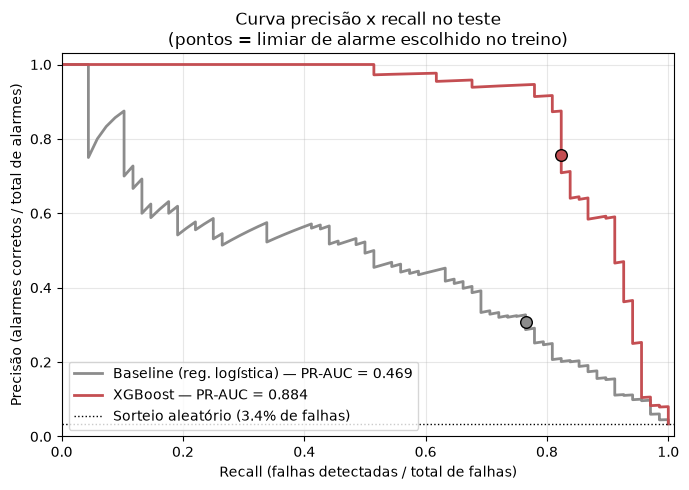

In [5]:
fig = plot_pr_curves(y_test, proba_base, proba_xgb, THR_BASE, THR)
plt.show()

**Leitura:**

- O **baseline** até pega muitas falhas, mas à custa de **centenas de alarmes falsos** — a equipe de manutenção logo passaria a ignorar os alertas.
- O **XGBoost** mantém recall parecido com uma fração dos alarmes falsos. A curva vermelha fica bem acima da cinza em praticamente todo o gráfico (PR-AUC ≈ 0,88 contra ≈ 0,47).

## 4. O limiar de alarme é uma decisão de manutenção

O modelo não diz "vai falhar" ou "não vai" — ele dá uma **probabilidade**. O **limiar** é a regra de disparo do alarme, como o *setpoint* de um alarme de temperatura no supervisório:

- **Limiar baixo** → mais falhas detectadas, mas mais paradas desnecessárias;
- **Limiar alto** → menos alarmes falsos, mas mais falhas passam sem aviso.

O limiar **foi escolhido sem olhar o teste**: usei as previsões *out-of-fold* da validação cruzada no treino (cada registro previsto por um modelo que não o viu) e peguei o limiar que maximiza **F2**. A tabela abaixo é justamente o "cardápio" que eu levaria para o gestor de manutenção — calculado **só com dados de treino**:

In [6]:
# Previsões out-of-fold no treino (mesmas dobras e hiperparâmetros do src/train.py)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score

spw = (y_train == 0).sum() / y_train.sum()
oof = cross_val_predict(make_xgb(spw, **busca["melhores_parametros"]), X_train, y_train,
                        cv=get_cv(), method="predict_proba", n_jobs=-1)[:, 1]
cardapio = []
for t in [0.1, 0.2, 0.3, 0.4, THR, 0.6, 0.7, 0.8, 0.9]:
    alarme = oof >= t
    cardapio.append({"limiar": round(t, 4),
                     "recall (falhas pegas)": recall_score(y_train, alarme),
                     "precisão (alarmes corretos)": precision_score(y_train, alarme),
                     "falhas pegas": f"{int((alarme & (y_train == 1)).sum())} de {int(y_train.sum())}",
                     "alarmes falsos": int((alarme & (y_train == 0)).sum())})
print(f"Limiar escolhido (máximo F2 out-of-fold): {THR}")
pd.DataFrame(cardapio)

Limiar escolhido (máximo F2 out-of-fold): 0.4969


,limiar,recall (falhas pegas),precisão (alarmes corretos),falhas pegas,alarmes falsos
0,0.100,0.893,0.419,242 de 271,335
1,0.200,0.863,0.542,234 de 271,198
2,0.300,0.852,0.613,231 de 271,146
3,0.400,0.830,0.682,225 de 271,105
4,0.497,0.823,0.726,223 de 271,84
5,0.600,0.793,0.776,215 de 271,62
6,0.700,0.782,0.812,212 de 271,49
7,0.800,0.756,0.854,205 de 271,35
8,0.900,0.705,0.897,191 de 271,22


O máximo de F2 caiu em **≈ 0,497**, praticamente o limiar padrão de 0,5 — por isso, no teste, os resultados do XGBoost nos dois limiares são idênticos.
Isso não é regra geral — provavelmente acontece porque o `scale_pos_weight` já "empurra" as probabilidades a favor da classe falha. Para o baseline, o limiar ótimo pelo mesmo critério foi bem diferente (≈ 0,73).

Numa fábrica real, o limiar deveria vir do **custo** de cada erro: se uma falha não detectada custa, por exemplo, 20 vezes mais que uma inspeção, vale baixar o limiar e aceitar mais alarmes.

O gráfico mostra como recall e precisão se movem com o limiar **no teste** (só para visualização — a escolha já estava feita):

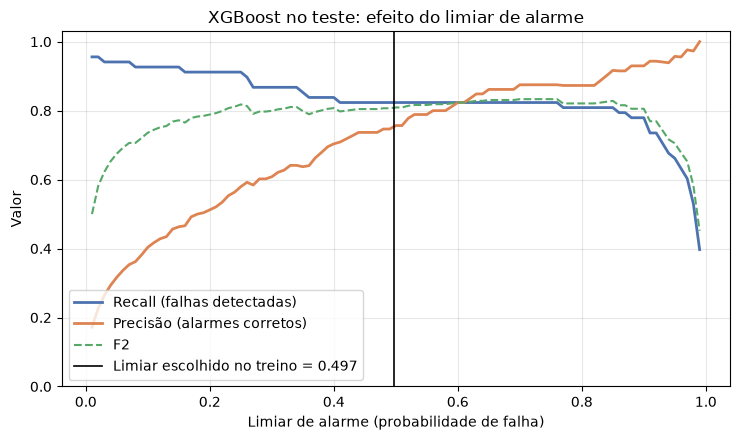

In [7]:
fig = plot_threshold_curve(y_test, proba_xgb, THR)
plt.show()

## 5. Matriz de confusão do modelo final

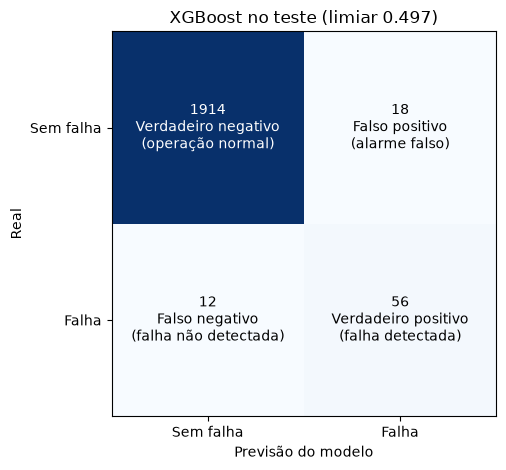

Falhas detectadas: 56 de 68 | alarmes falsos: 18 em 1932 registros sem falha


In [8]:
fig = plot_confusion_matrix(y_test, proba_xgb, THR, f"XGBoost no teste (limiar {THR:.3f})")
plt.show()
final = compute_metrics(y_test, proba_xgb, THR)
print(f"Falhas detectadas: {final['falhas_detectadas']} | alarmes falsos: {final['alarmes_falsos']} "
      f"em {int((y_test == 0).sum())} registros sem falha")

## 6. Onde o modelo erra — e por quê

Para interpretar os erros, cruzo as previsões com os **modos de falha reais** (o modelo nunca viu essas colunas; aqui elas servem só como "laudo").

In [9]:
expl, contexto = compute_test_shap()
falhas = contexto[contexto["real"] == 1]
por_modo = pd.DataFrame({
    "falhas no teste": falhas[FAILURE_MODES].sum(),
    "detectadas": falhas.loc[falhas["previsto"] == 1, FAILURE_MODES].sum(),
})
por_modo["recall do modo"] = (por_modo["detectadas"] / por_modo["falhas no teste"]).round(2)
display(por_modo)

fn = falhas[falhas["previsto"] == 0]
print(f"Falhas não detectadas: {len(fn)}")
print("  por modo:", fn[FAILURE_MODES].sum().to_dict(), "| sem nenhum modo marcado:", int((fn[FAILURE_MODES].sum(axis=1) == 0).sum()))

fp = contexto[(contexto["real"] == 0) & (contexto["previsto"] == 1)]
desgaste_fp = X_test.loc[fp.index, "tool_wear_min"]
print(f"Alarmes falsos: {len(fp)} | com desgaste da ferramenta > 200 min: {int((desgaste_fp > 200).sum())}")

[dados] CSV já existe em data/raw/ai4i2020.csv — download ignorado.


,falhas no teste,detectadas,recall do modo
TWF,10,1,0.10
HDF,29,28,0.97
PWF,13,13,1.00
OSF,16,16,1.00
RNF,0,0,NaN


Falhas não detectadas: 12
  por modo: {'TWF': 9, 'HDF': 1, 'PWF': 0, 'OSF': 0, 'RNF': 0} | sem nenhum modo marcado: 2
Alarmes falsos: 18 | com desgaste da ferramenta > 200 min: 15


**Leitura:**

- Falhas de **dissipação de calor (HDF)**, **potência (PWF)** e **sobrecarga (OSF)** seguem regras físicas claras, e o modelo pega quase todas.
- O ponto fraco é a **falha por desgaste da ferramenta (TWF)**: pela descrição do dataset, a ferramenta falha *ou é trocada* num momento **sorteado** entre 200 e 240 min de uso. Os sensores mostram que a ferramenta está "na zona de risco", mas não quando exatamente ela vai quebrar.
- O mesmo motivo explica boa parte dos **alarmes falsos**: ferramentas acima de 200 min que, por sorteio, ainda não tinham falhado. Na vida real, esse alarme viraria uma **troca preventiva de ferramenta** — o que pode até ser a decisão certa.

### Incerteza: intervalo de confiança por bootstrap

Com só **68 falhas** no teste, cada falha detectada a mais ou a menos muda o recall em ~1,5 ponto percentual. Reamostrando o teste 2.000 vezes (bootstrap), obtemos uma faixa plausível para as métricas:

In [10]:
ic = metrics["teste"]["ic95_xgboost_limiar_escolhido"]
print(f"Recall   : {final['recall']:.3f}  (IC 95%: {ic['recall'][0]:.3f} – {ic['recall'][1]:.3f})")
print(f"Precisão : {final['precisao']:.3f}  (IC 95%: {ic['precisao'][0]:.3f} – {ic['precisao'][1]:.3f})")
print(f"PR-AUC   : {final['pr_auc']:.3f}  (IC 95%: {ic['pr_auc'][0]:.3f} – {ic['pr_auc'][1]:.3f})")

Recall   : 0.824  (IC 95%: 0.727 – 0.908)
Precisão : 0.757  (IC 95%: 0.659 – 0.853)
PR-AUC   : 0.884  (IC 95%: 0.811 – 0.941)


Ou seja: o recall "verdadeiro" do modelo pode estar razoavelmente abaixo ou acima do valor pontual. É importante apresentar essa faixa, e não só um número bonito.

## 7. SHAP: quais sensores mais pesam na decisão?

O **SHAP** distribui a "culpa" de cada previsão entre as variáveis de entrada. Os valores estão em *log-odds* (logaritmo da chance de falha): **positivo empurra para "falha"**, **negativo para "operação normal"**.

### Visão global

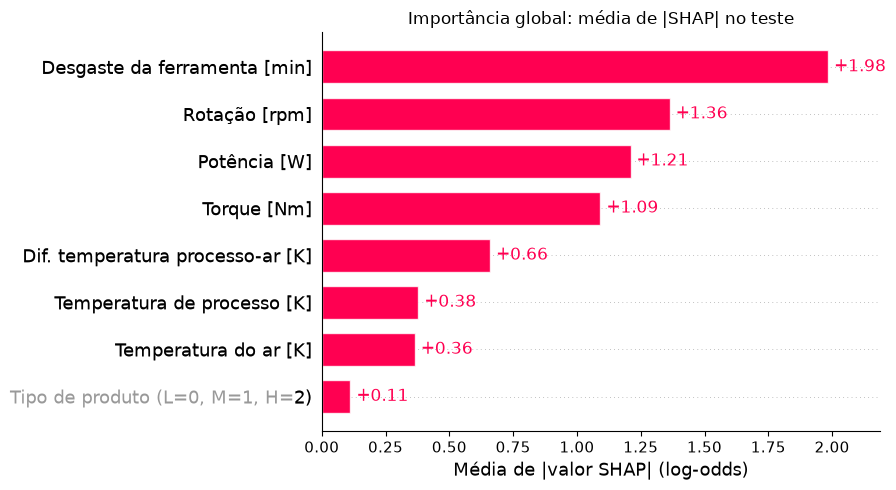

,média |SHAP|
Desgaste da ferramenta [min],1.984
Rotação [rpm],1.364
Potência [W],1.210
Torque [Nm],1.092
Dif. temperatura processo-ar [K],0.660
Temperatura de processo [K],0.379
Temperatura do ar [K],0.365
"Tipo de produto (L=0, M=1, H=2)",0.113


In [11]:
fig = plot_importance(expl)
plt.show()
mean_abs_shap(expl).round(3).to_frame("média |SHAP|")

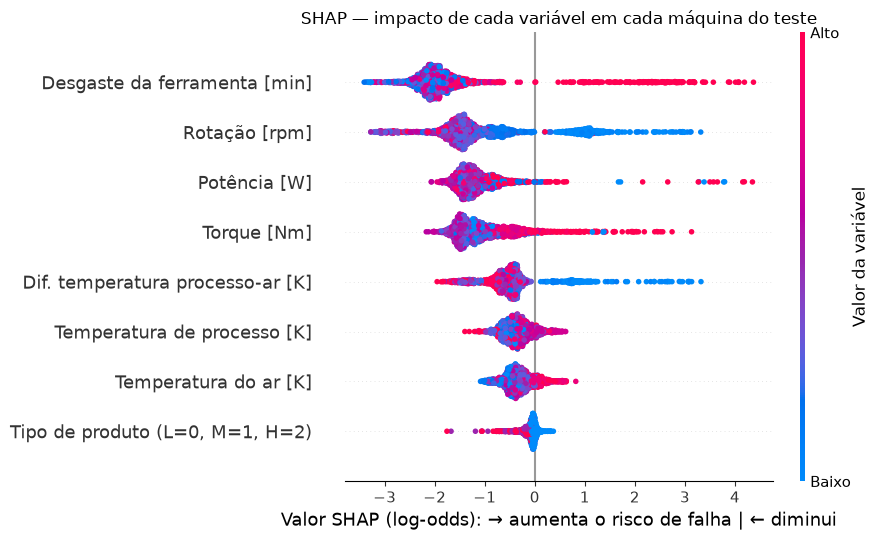

In [12]:
fig = plot_beeswarm(expl)
plt.show()

Um zoom no fator mais importante: a contribuição média do **desgaste da ferramenta** por faixa de minutos de uso.

In [13]:
shap_desgaste = pd.Series(expl.values[:, config["features"].index("tool_wear_min")], index=X_test.index)
faixas = pd.cut(X_test["tool_wear_min"], [0, 150, 180, 190, 200, 205, 210, 220, 260], include_lowest=True)
shap_desgaste.groupby(faixas, observed=True).agg(["mean", "count"]).rename(
    columns={"mean": "SHAP médio (log-odds)", "count": "registros"}).rename_axis("desgaste [min]")

,SHAP médio (log-odds),registros
desgaste [min],,
"(-0.001, 150.0]",-2.043,1391
"(150.0, 180.0]",-1.927,272
"(180.0, 190.0]",-1.546,83
"(190.0, 200.0]",-1.411,87
"(200.0, 205.0]",0.634,45
"(205.0, 210.0]",2.177,46
"(210.0, 220.0]",2.496,50
"(220.0, 260.0]",3.012,26


**Leitura (cada ponto é uma máquina do teste; cor = valor do sensor):**

- **Desgaste da ferramenta** é o fator mais importante: valores altos (vermelho) empurram fortemente para falha — exatamente o que um técnico de manutenção esperaria. A tabela acima mostra que a contribuição média **troca de sinal logo acima de 200 min**: o modelo "descobriu" sozinho a vida útil da ferramenta.
- **Rotação baixa** (azul) aumenta o risco: rotação baixa com torque alto é o cenário de sobrecarga e de pouca dissipação de calor.
- **Potência** e **torque** altos aumentam o risco; alguns pontos de potência **muito baixa** também — são as falhas de potência fora da janela de operação.
- **Diferença de temperatura baixa** (azul) aumenta o risco: o calor não está saindo do processo.
- O **tipo de produto** quase não pesa depois que o modelo já conhece os sensores.

As duas variáveis criadas na preparação (**potência** e **diferença de temperatura**) aparecem entre as mais importantes — conhecimento de processo virando variável do modelo.

### Visão local: por que *esta* máquina foi sinalizada?

Três casos **reais** do teste, escolhidos por regras fixas (sem seleção manual): a falha detectada com maior probabilidade, a falha não detectada com menor probabilidade e o alarme falso com maior probabilidade.

In [14]:
casos = select_cases(contexto)
for nome, i in casos.items():
    print(f"{TITULOS[nome]}: {describe_case(contexto, i)}")

Falha detectada (verdadeiro positivo): UDI 4343 (tipo M) — probabilidade 99.9%, real=falha, modo(s): HDF, PWF
Falha NÃO detectada (falso negativo): UDI 1997 (tipo M) — probabilidade 0.2%, real=falha, modo(s): TWF
Alarme falso (falso positivo): UDI 3795 (tipo M) — probabilidade 98.2%, real=sem falha, modo(s): nenhum


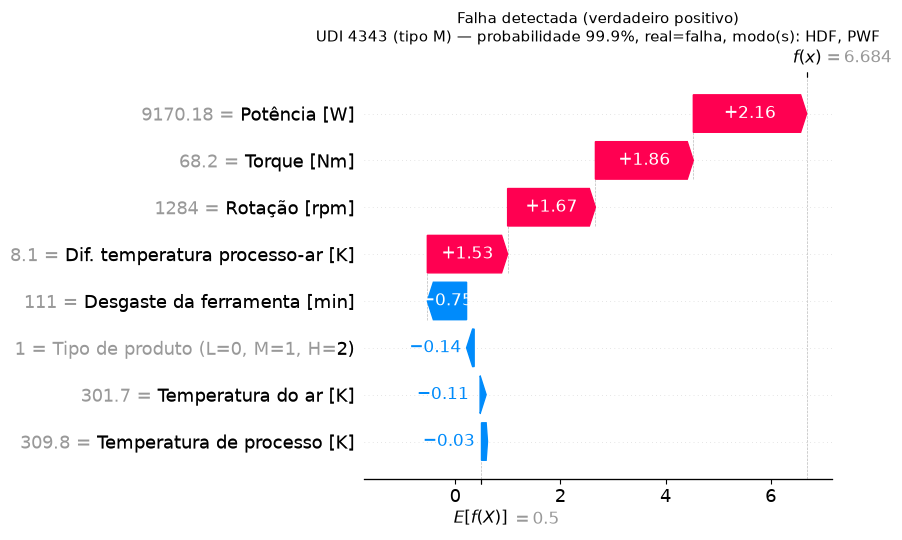

In [15]:
i = casos["falha_detectada"]
fig = plot_waterfall(expl[i], f"{TITULOS['falha_detectada']}\n{describe_case(contexto, i)}")
plt.show()

**Falha detectada:** potência acima de 9.000 W, torque muito alto e rotação baixa somam quase todo o risco. O laudo confirma: falha de **potência (PWF)** e de **dissipação de calor (HDF)** ao mesmo tempo. O operador receberia um alarme com o motivo claro: *"máquina trabalhando acima da potência máxima, com rotação baixa"*.

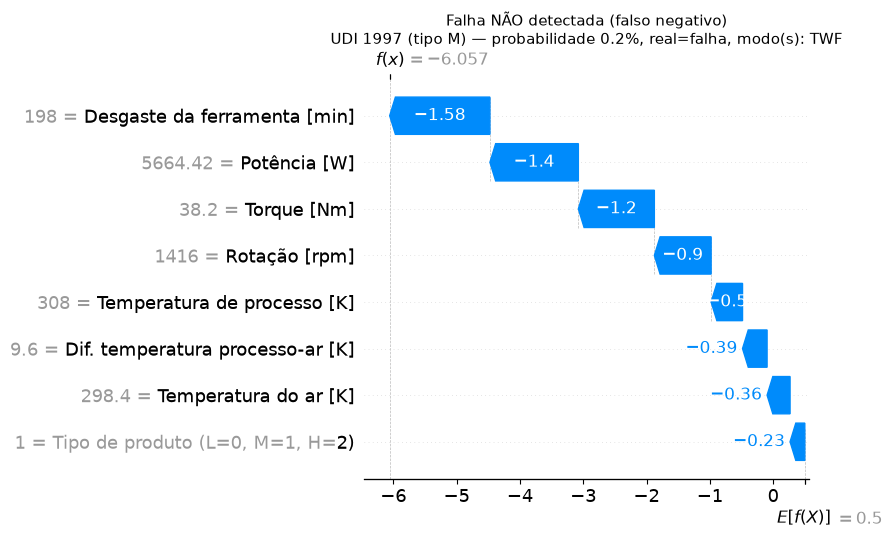

In [16]:
i = casos["falha_nao_detectada"]
fig = plot_waterfall(expl[i], f"{TITULOS['falha_nao_detectada']}\n{describe_case(contexto, i)}")
plt.show()

**Falha não detectada:** todas as variáveis apontam para "operação normal" — potência e torque em faixa normal e ferramenta com **198 min**, logo **abaixo** da zona de risco que o modelo aprendeu (a partir de ~200 min). O laudo diz **TWF** (desgaste da ferramenta): uma quebra que, pelas regras do dataset, é em boa parte sorteio. Nenhum sensor avisava — é o tipo de falha que pede **outra informação** (ex.: vibração, emissão acústica ou histórico de trocas de ferramenta).

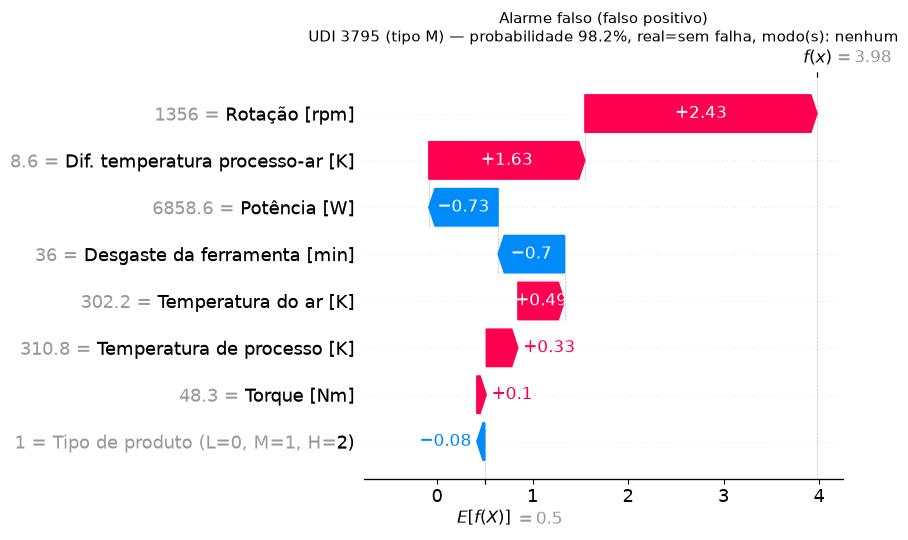

In [17]:
i = casos["alarme_falso"]
fig = plot_waterfall(expl[i], f"{TITULOS['alarme_falso']}\n{describe_case(contexto, i)}")
plt.show()

**Alarme falso:** a rotação baixa (1.356 rpm) e a diferença de temperatura de **8,6 K** levaram a probabilidade a ~98%. Esse registro está **exatamente na fronteira** da regra de falha por dissipação de calor descrita pelo autor do dataset (diferença **abaixo** de 8,6 K e rotação abaixo de 1.380 rpm). Na prática, é uma máquina operando no limite — um alarme "falso" que, na fábrica, justificaria uma verificação do sistema de refrigeração.

## 8. Limitações

- **Dataset sintético.** Os dados foram gerados por regras conhecidas para imitar uma máquina real. Em uma planta de verdade há ruído de sensor, deriva de calibração, dados faltantes e mudanças de processo que não aparecem aqui.
- **Regras fáceis de aprender.** A falha de potência (PWF) é uma regra fixa: na exploração, **todos os 95** registros com potência fora de 3.500–9.000 W falharam. Com a variável `power_w`, o modelo aprende isso quase de graça — parte do desempenho vem dessa "regra embutida".
- **Rótulos inconsistentes.** No dataset completo há 9 falhas sem nenhum modo marcado e 18 registros com `RNF = 1` mas sem falha registrada. O alvo foi usado como está.
- **Poucas falhas no teste.** São só 68; as métricas têm incerteza considerável (veja o intervalo de confiança acima).
- **Sem dimensão de tempo.** Cada linha é um registro independente; o modelo não usa tendência (ex.: temperatura subindo nas últimas horas), que seria essencial para prever falhas com antecedência numa aplicação real.
- **Falhas aleatórias** (TWF parcialmente e RNF) não são previsíveis com esses sensores.
- **Custos não modelados.** O limiar foi escolhido por F2; numa fábrica, deveria vir do custo real de uma falha não detectada × uma parada desnecessária.

## 9. Conclusão

- O XGBoost detecta a maior parte das falhas do teste com poucos alarmes falsos, com PR-AUC muito acima do baseline e do "modelo que nunca falha".
- O limiar de alarme foi escolhido de forma honesta (validação cruzada no treino, critério F2) e pode ser ajustado conforme o custo de cada erro.
- O SHAP mostra que o modelo usa o que um técnico de manutenção usaria: **desgaste da ferramenta, rotação, potência, torque e dissipação de calor** — e explica cada alarme individualmente.

**Próximo passo:** um app em Streamlit onde o usuário informa as leituras dos sensores e recebe a probabilidade de falha com a explicação SHAP.